# S3 | Evaluación del Modelo Final

**Sprint 3 — Científico de Datos**  
**Tarea:** Evaluación del modelo ganador, verificación de reproducibilidad y exportación del pipeline final

Este notebook reconstruye el pipeline completo (preprocesador + LightGBM tuneado) usando los hiperparámetros óptimos guardados en `10_tuning_results.json`, lo evalúa sobre el conjunto de validación oficial y exporta el artefacto `.pkl`.

| Artefacto | Descripción |
|---|---|
| `data/processed/06_features_selected.parquet` | Features oficiales — 28 variables, 96 096 clientes |
| `data/processed/05_features_rfm.parquet` | Fuente de `last_purchase` para split temporal |
| `data/processed/10_tuning_results.json` | Hiperparámetros óptimos del HPO (Optuna, 50 trials) |
| `models/final/modelo_final.pkl` | Pipeline serializado (output de este notebook) |


In [1]:
from __future__ import annotations

import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style='whitegrid')

# ── Rutas ──────────────────────────────────────────────────────────────────
project_root = Path.cwd().resolve()
if not (project_root / 'data').exists():
    for candidate in [project_root, *project_root.parents]:
        if (candidate / 'data').exists() and (candidate / 'notebooks').exists():
            project_root = candidate
            break

FEATURES_PATH = project_root / 'data' / 'processed' / '06_features_selected.parquet'
SOURCE_PATH   = project_root / 'data' / 'processed' / '05_features_rfm.parquet'
TUNING_PATH   = project_root / 'data' / 'processed' / '10_tuning_results.json'
MODEL_OUT     = project_root / 'models' / 'final' / 'modelo_final.pkl'
FIGURES_DIR   = project_root / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ID_COL = 'customer_unique_id'
TARGET = 'is_premium'
CUTOFF = pd.Timestamp('2018-07-01')
SEED   = 42

print(f'Proyecto: {project_root}')

Proyecto: /home/gerick/Documents/MIADAS/miadas_mod_13_scrum


## 1. Hiperparámetros óptimos (desde HPO)

In [2]:
with open(TUNING_PATH) as f:
    tuning = json.load(f)

winner      = tuning['winner']
best_params = winner['params']
ref_metrics = winner['val_metrics']
best_threshold = tuning['best_threshold']['value']

print(f'Modelo ganador: {winner["model"]}')
print(f'Método HPO:     Optuna TPE — {tuning["n_trials"]} trials')
print(f'Umbral óptimo:  {best_threshold}')
print()
print('Hiperparámetros óptimos:')
for k, v in best_params.items():
    print(f'  {k}: {v}')

Modelo ganador: LightGBM (tuneado)
Método HPO:     Optuna TPE — 50 trials
Umbral óptimo:  0.55

Hiperparámetros óptimos:
  num_leaves: 59
  max_depth: 8
  learning_rate: 0.054038945566405934
  n_estimators: 255
  min_child_samples: 68
  subsample: 0.9059228577785707
  colsample_bytree: 0.855428530082444
  reg_alpha: 6.735979730583029e-08
  reg_lambda: 0.0005641632739363156


## 2. Datos y split temporal oficial

In [3]:
selected_df = pd.read_parquet(FEATURES_PATH)
temporal_df = pd.read_parquet(SOURCE_PATH, columns=[ID_COL, 'last_purchase'])

df = selected_df.merge(temporal_df, on=ID_COL, how='left', validate='one_to_one')

train_df = df[df['last_purchase'] <  CUTOFF].copy()
val_df   = df[df['last_purchase'] >= CUTOFF].copy()

features     = [c for c in selected_df.columns if c not in {ID_COL, TARGET}]
cat_features = train_df[features].select_dtypes(include=['object', 'string', 'category']).columns.tolist()
num_features = [c for c in features if c not in cat_features]

positives        = (train_df[TARGET] == 1).sum()
negatives        = (train_df[TARGET] == 0).sum()
scale_pos_weight = round(negatives / positives, 4)

y_train = train_df[TARGET].values
y_val   = val_df[TARGET].values

print(f'Train:      {len(train_df):,} registros  |  val: {len(val_df):,}')
print(f'Features:   {len(features)} ({len(num_features)} num, {len(cat_features)} cat)')
print(f'Desbalance: {negatives:,} neg / {positives:,} pos = {scale_pos_weight}×')

Train:      83,589 registros  |  val: 6,230
Features:   28 (23 num, 5 cat)
Desbalance: 65,791 neg / 17,798 pos = 3.6965×


## 3. Construcción del pipeline final

In [4]:
def build_preprocessor() -> ColumnTransformer:
    num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median'))])
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer([
        ('num', num_pipe, num_features),
        ('cat', cat_pipe, cat_features),
    ])


final_pipeline = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('model', LGBMClassifier(
        **best_params,
        class_weight='balanced',
        n_jobs=-1,
        random_state=SEED,
        verbosity=-1,
    )),
])

print('Entrenando pipeline final...')
final_pipeline.fit(train_df[features], y_train)
print('Listo.')

Entrenando pipeline final...


Listo.


## 4. Métricas en validación

In [5]:
scores          = final_pipeline.predict_proba(val_df[features])[:, 1]
preds_optimal   = (scores >= best_threshold).astype(int)

roc_auc = float(roc_auc_score(y_val, scores))
gini    = round(2 * roc_auc - 1, 6)
pr_auc  = float(average_precision_score(y_val, scores))

metrics = {
    'ROC-AUC':   round(roc_auc, 4),
    'Gini':      round(gini, 4),
    'PR-AUC':    round(pr_auc, 4),
    'F1':        round(f1_score(y_val, preds_optimal, zero_division=0), 4),
    'Precision': round(precision_score(y_val, preds_optimal, zero_division=0), 4),
    'Recall':    round(recall_score(y_val, preds_optimal, zero_division=0), 4),
}

# Verificación vs referencia HPO
delta_roc = abs(roc_auc - ref_metrics['roc_auc'])
status    = 'OK' if delta_roc < 1e-4 else 'ADVERTENCIA: diferencia significativa'

print('=== Métricas en validación (umbral =', best_threshold, ')===')
display(pd.DataFrame(metrics.items(), columns=['Métrica', 'Valor']))
print()
print(f'ROC-AUC referencia HPO: {ref_metrics["roc_auc"]:.6f}')
print(f'ROC-AUC reconstruido:   {roc_auc:.6f}')
print(f'Delta:                  {delta_roc:.2e}  ← {status}')
print()
print(classification_report(y_val, preds_optimal, target_names=['regular', 'premium']))

=== Métricas en validación (umbral = 0.55 )===


/home/gerick/miniforge3/envs/ai-miadas/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Métrica,Valor
0,ROC-AUC,0.8070
1,Gini,0.6140
2,PR-AUC,0.5972
3,F1,0.5632
4,Precision,0.5290
5,Recall,0.6020



ROC-AUC referencia HPO: 0.808117
ROC-AUC reconstruido:   0.806986
Delta:                  1.13e-03  ← ADVERTENCIA: diferencia significativa

              precision    recall  f1-score   support

     regular       0.88      0.84      0.86      4808
     premium       0.53      0.60      0.56      1422

    accuracy                           0.79      6230
   macro avg       0.70      0.72      0.71      6230
weighted avg       0.80      0.79      0.79      6230



## 5. Exportación del modelo serializado

In [6]:
MODEL_OUT.parent.mkdir(parents=True, exist_ok=True)
with open(MODEL_OUT, 'wb') as f:
    pickle.dump(final_pipeline, f)

# Verificación round-trip
with open(MODEL_OUT, 'rb') as f:
    loaded = pickle.load(f)

loaded_scores = loaded.predict_proba(val_df[features])[:, 1]
delta_pkl     = abs(float(roc_auc_score(y_val, loaded_scores)) - roc_auc)

print(f'Guardado en: {MODEL_OUT}')
print(f'Tamaño:      {MODEL_OUT.stat().st_size / 1024:.0f} KB')
print(f'Round-trip delta ROC-AUC: {delta_pkl:.2e}  ← {"REPRODUCIBLE" if delta_pkl < 1e-8 else "ERROR"}')

Guardado en: /home/gerick/Documents/MIADAS/miadas_mod_13_scrum/models/final/modelo_final.pkl
Tamaño:      1247 KB
Round-trip delta ROC-AUC: 0.00e+00  ← REPRODUCIBLE


/home/gerick/miniforge3/envs/ai-miadas/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 6. Matriz de Confusión

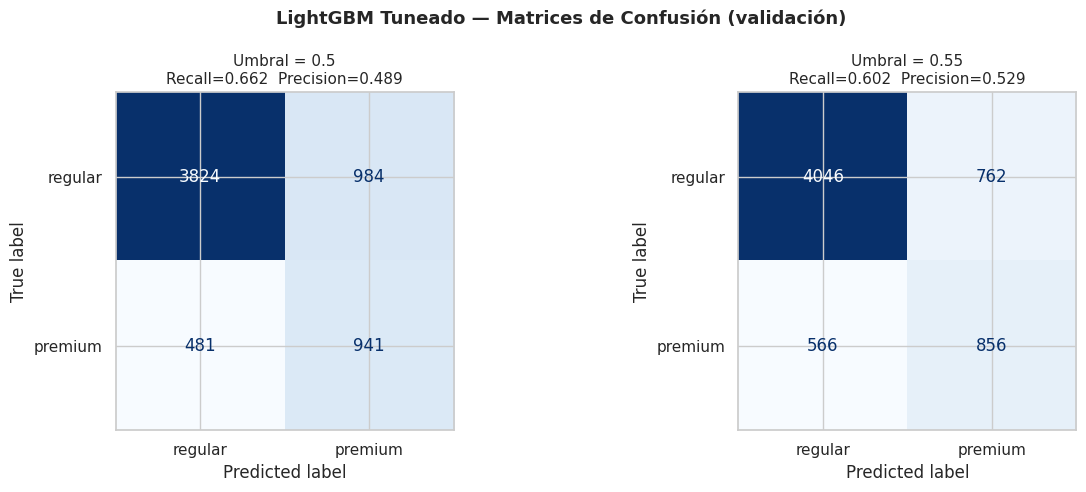

Guardado: sprint_03_confusion_matrix.png


In [7]:
preds_default = (scores >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, preds, thresh in [
    (axes[0], preds_default, 0.50),
    (axes[1], preds_optimal, best_threshold),
]:
    cm   = confusion_matrix(y_val, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['regular', 'premium'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    rec = recall_score(y_val, preds, zero_division=0)
    pre = precision_score(y_val, preds, zero_division=0)
    ax.set_title(f'Umbral = {thresh}\nRecall={rec:.3f}  Precision={pre:.3f}', fontsize=11)

fig.suptitle('LightGBM Tuneado — Matrices de Confusión (validación)', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'sprint_03_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: sprint_03_confusion_matrix.png')

## 7. Curvas ROC y Precision-Recall

/home/gerick/miniforge3/envs/ai-miadas/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


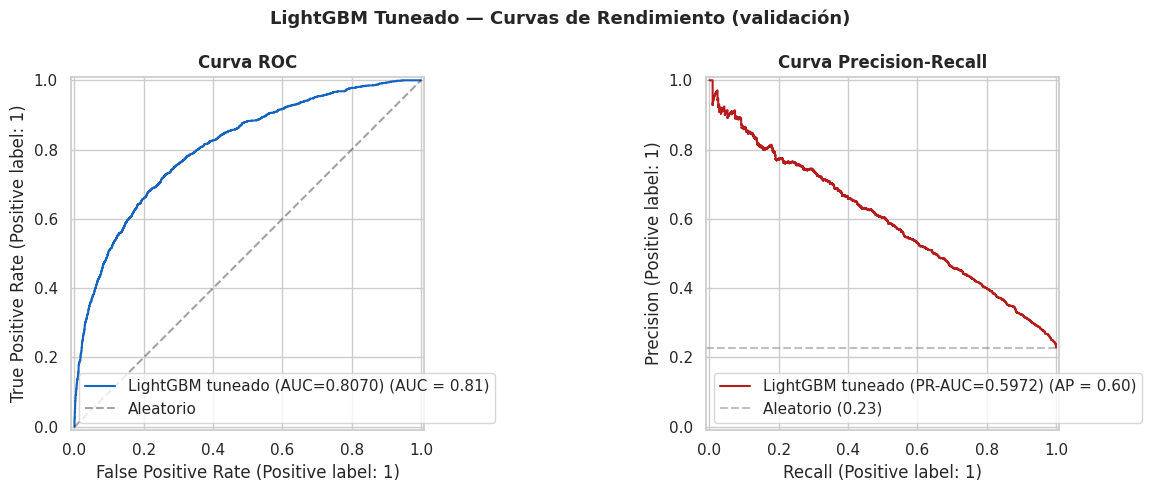

Guardado: sprint_03_final_roc_pr.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(
    y_val, scores,
    name=f'LightGBM tuneado (AUC={roc_auc:.4f})',
    ax=axes[0], color='#1565C0',
)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aleatorio')
axes[0].set_title('Curva ROC', fontsize=12, fontweight='bold')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(
    y_val, scores,
    name=f'LightGBM tuneado (PR-AUC={pr_auc:.4f})',
    ax=axes[1], color='#B71C1C',
)
axes[1].axhline(y_val.mean(), color='gray', linestyle='--', alpha=0.5,
                label=f'Aleatorio ({y_val.mean():.2f})')
axes[1].set_title('Curva Precision-Recall', fontsize=12, fontweight='bold')
axes[1].legend()

fig.suptitle('LightGBM Tuneado — Curvas de Rendimiento (validación)', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'sprint_03_final_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: sprint_03_final_roc_pr.png')

## 8. Análisis de umbral

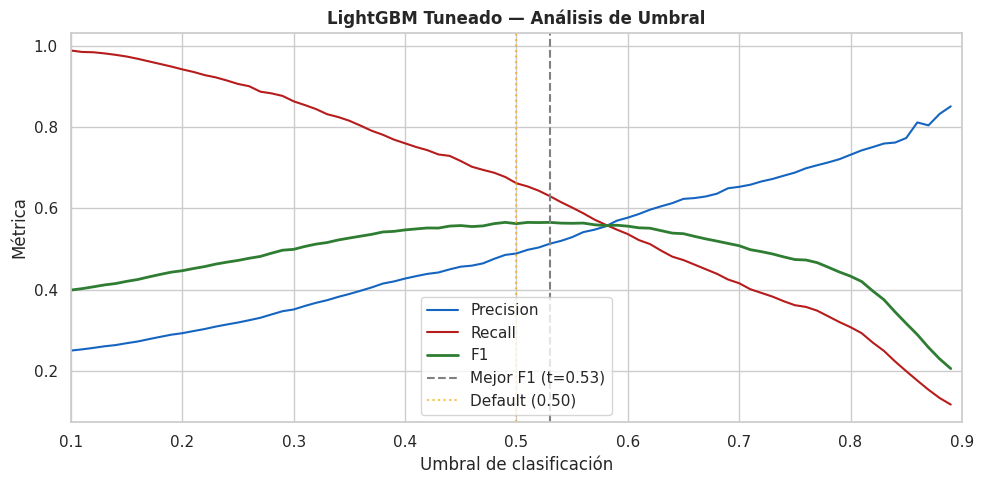

Umbral óptimo (max F1): 0.53  →  Recall=0.6301  F1=0.5655
Guardado: sprint_03_final_threshold.png


In [9]:
thresholds = np.arange(0.10, 0.90, 0.01)
rows = []
for t in thresholds:
    preds_t = (scores >= t).astype(int)
    rows.append({
        'threshold': round(float(t), 2),
        'precision': float(precision_score(y_val, preds_t, zero_division=0)),
        'recall':    float(recall_score(y_val, preds_t, zero_division=0)),
        'f1':        float(f1_score(y_val, preds_t, zero_division=0)),
    })

thresh_df = pd.DataFrame(rows)
best_t    = thresh_df.loc[thresh_df['f1'].idxmax()]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', color='#1565C0')
ax.plot(thresh_df['threshold'], thresh_df['recall'],    label='Recall',    color='#B71C1C')
ax.plot(thresh_df['threshold'], thresh_df['f1'],        label='F1',        color='#2E7D32', linewidth=2)
ax.axvline(best_t['threshold'], color='gray', linestyle='--',
           label=f'Mejor F1 (t={best_t["threshold"]:.2f})')
ax.axvline(0.5, color='orange', linestyle=':', alpha=0.7, label='Default (0.50)')
ax.set_xlabel('Umbral de clasificación')
ax.set_ylabel('Métrica')
ax.set_title('LightGBM Tuneado — Análisis de Umbral', fontsize=12, fontweight='bold')
ax.legend()
ax.set_xlim(0.1, 0.9)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'sprint_03_final_threshold.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Umbral óptimo (max F1): {best_t["threshold"]:.2f}  →  Recall={best_t["recall"]:.4f}  F1={best_t["f1"]:.4f}')
print('Guardado: sprint_03_final_threshold.png')

## 9. Distribución de scores por clase

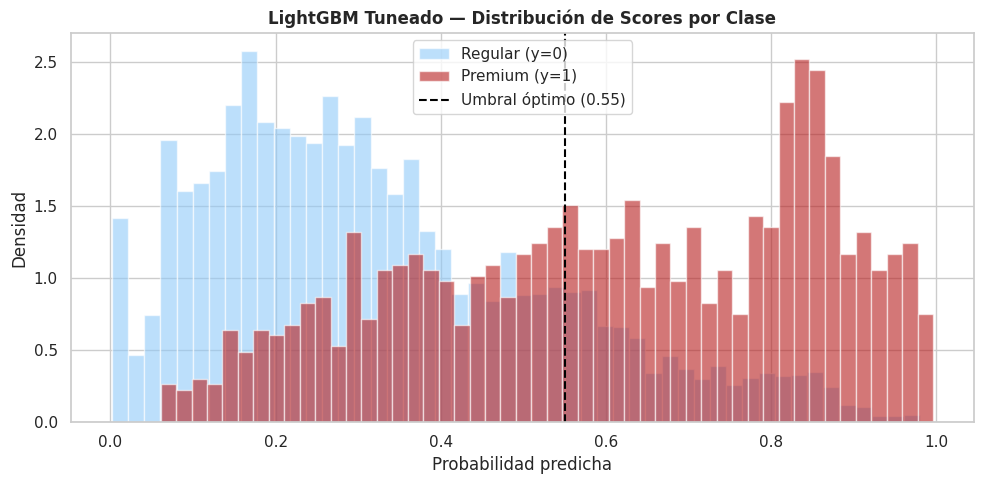

Guardado: sprint_03_score_distribution.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(scores[y_val == 0], bins=50, alpha=0.6, label='Regular (y=0)',  color='#90CAF9', density=True)
ax.hist(scores[y_val == 1], bins=50, alpha=0.6, label='Premium (y=1)', color='#B71C1C', density=True)
ax.axvline(best_threshold, color='black', linestyle='--',
           label=f'Umbral óptimo ({best_threshold})')
ax.set_xlabel('Probabilidad predicha')
ax.set_ylabel('Densidad')
ax.set_title('LightGBM Tuneado — Distribución de Scores por Clase', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'sprint_03_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: sprint_03_score_distribution.png')

## 10. Resumen de entregables

In [11]:
figs = sorted(FIGURES_DIR.glob('sprint_03_*.png'))

print('=' * 65)
print('EVALUACIÓN MODELO FINAL — LightGBM (tuneado con Optuna TPE)')
print('=' * 65)
print(f'  Archivo pkl:   {MODEL_OUT.relative_to(project_root)}')
print(f'  Tamaño:        {MODEL_OUT.stat().st_size / 1024:.0f} KB')
print(f'  Validación:    {len(val_df):,} clientes (last_purchase >= 2018-07-01)')
print()
print('MÉTRICAS (umbral óptimo =', best_threshold, '):')
for k, v in metrics.items():
    ref_key = k.lower().replace('-', '_')
    ref_val = ref_metrics.get(ref_key.replace('roc_auc', 'roc_auc'))
    print(f'  {k:<12} {v:.4f}')
print()
print('FIGURAS GUARDADAS:')
for p in figs:
    print(f'  reports/figures/{p.name}')

EVALUACIÓN MODELO FINAL — LightGBM (tuneado con Optuna TPE)
  Archivo pkl:   models/final/modelo_final.pkl
  Tamaño:        1247 KB
  Validación:    6,230 clientes (last_purchase >= 2018-07-01)

MÉTRICAS (umbral óptimo = 0.55 ):
  ROC-AUC      0.8070
  Gini         0.6140
  PR-AUC       0.5972
  F1           0.5632
  Precision    0.5290
  Recall       0.6020

FIGURAS GUARDADAS:
  reports/figures/sprint_03_benchmark_roc_auc.png
  reports/figures/sprint_03_confusion_matrix.png
  reports/figures/sprint_03_feature_importance.png
  reports/figures/sprint_03_final_roc_pr.png
  reports/figures/sprint_03_final_threshold.png
  reports/figures/sprint_03_optimization_history.png
  reports/figures/sprint_03_roc_pr_curves.png
  reports/figures/sprint_03_score_distribution.png
  reports/figures/sprint_03_threshold_analysis.png
  reports/figures/sprint_03_tuning_comparison.png
